In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


# Vazifa

Quyidagi ma'lumotlar to'plami Hindistonning Qandli diabet va buyrak kasalliklari milliy institutidan olingan. Maqsad diagnostik o'lchovlar asosida bemorda diabet bor-yo'qligini taxmin qilishdir.

# Tarkib

Dataset ichida barcha bemorlar kamida 21 yoshli ayollari.


# Ustunlar


*   Pregnancies: homilador bo'lish soni
*   Glucose: glyukozaga test natijasi
* BloodPressure: diastolik qon bosimi (mm Hg)
* SkinThickness: Triceps teri burmasining qalinligi (mm)
* Insulin: 2 soatlik sarum insulini (mu U/ml)
* BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)
* DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi
* Age: Yosh (yil)
* Outcome: Class (0 - diabet yo'q, 1 - diabet)


Pregnancies: homilador bo'lish soni
Glucose: glyukozaga test natijasi
BloodPressure: diastolik qon bosimi (mm Hg)
SkinThickness: Triceps teri burmasining qalinligi (mm)
Insulin: 2 soatlik sarum insulini (mu U/ml)
BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)
DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi
Age: Yosh (yil)
Outcome: Class (0 - diabet yo'q, 1 - diabet)
# Datasetni men o'z GitHub akauntimga yuklab oldim va havola orqali [chaqirdim:ttps://raw.githubusercontent.com/dilshod12352005/data1/refs/heads/main/diabetes.csv](https://)

In [3]:
url="https://raw.githubusercontent.com/dilshod12352005/data1/refs/heads/main/diabetes.csv"
df=pd.read_csv(url)

In [4]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Datamizda nan qiymatlar yo'q toza ekan

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df_corr=df.corr().abs()
df_corr.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,0.081672,0.073535,0.017683,0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,0.113970,0.074752
Insulin,0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,0.113970,0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


# `Outcome` ustuni bilan qolgan ustunlar o'rtasidagi bog'liqlik.
`Outcome: Class (0 - diabet yo'q, 1 - diabet)`

In [7]:
df.corrwith(df['Outcome']).abs().sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [130]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


# `Etibor_bering`
# etibor qilsak Outcome ustuni bilan qolgan ustunlar correlatsiyasi unchalik yuqori emas . 4 ta ustun yaxshiroq ekan shu 4 ta ustuni o'zini olsak ham bo'ladi modelimiz kamroq adashadi . avval shu turishida ml qilib ko'rayik keyin 4 ta ustun bilan qilamiz

In [8]:
X=df.drop('Outcome', axis=1).values
y=df['Outcome']

In [9]:
X

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]])

# Train va test uchun ajratamiz

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=12)

##  Ma'lumotlarni normalizatsiya qilish.

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [12]:
X_train_scaler=scaler.transform(X_train)
X_test_scaler=scaler.transform(X_test)

###  Mashinali o'qitish modelini qurish (KNN algoritmi) k ni qiymatini 5 deb olib tutamiz

In [68]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaler, y_train)

KNeighborsClassifier()

# Model yordamida bashorat qilish (Prediction)

In [69]:
y_predict=knn.predict(X_test_scaler)

# Jaccard indeksini hisoblaymiz.
# Bu  bashorat qilingan natijalar bilan haqiqiy natijalar o'rtasidagi "kesishish" (o'xshashlik) darajasini ko'rsatadi.
Ko'rib turibmizki natija yaxshi ema qanchalik 1 ga yaqin bo'lsa shuncha yaxshi

In [64]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_predict)

np.float64(0.4794520547945205)

# Confusion Matrix yordamida modelning qayerda xato qilganini vizualizatsiya qilamiz.
# Bu jadval:
# - Haqiqiy sog'lomlarni nechtasini sog'lom deb topdi (True Negative)
# - Haqiqiy diabetlarni nechtasini diabet deb topdi (True Positive) ekanligini ko'rsatadi.

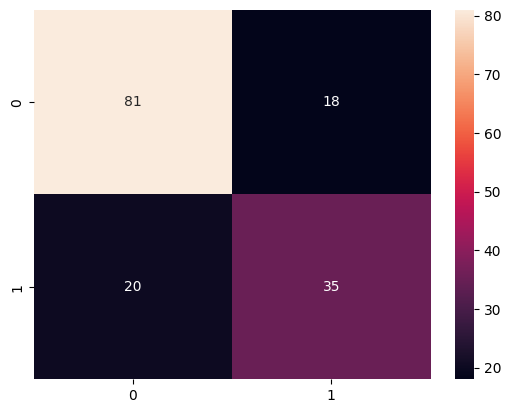

In [65]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

# Modelning barcha asosiy ko'rsatkichlarini (Precision, Recall, F1-score) jamlagan hisobot.
# Precision - bashorat qilingan diabetlarning necha foizi haqiqatda diabet?
# Recall - haqiqiy diabetlarning necha foizini modelimiz aniqlay oldi?
# F1-score - Precision va Recall o'rtasidagi muvozanatni ko'rsatadi.

In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



# Ko'rib turibmiz  `accuracy                           0.75       154` -> bu degani modelimizni umumiy aniqligi 75% ekan . Bu yaxshi emas nima qilamiz K ni qiymatni o'zgartiramiz

# Modelning aniqligini oshirish uchun eng maqbul K (qo'shnilar soni) qiymatini qidiramiz.
# Buning uchun 1 dan 20 gacha bo'lgan barcha K qiymatlarini tsikl (loop) yordamida sinab ko'ramiz.
Bu kodni yozishda menga AI yordam berdi

Eng yaxshi aniqlik: 0.81, K=15 bo'lganda


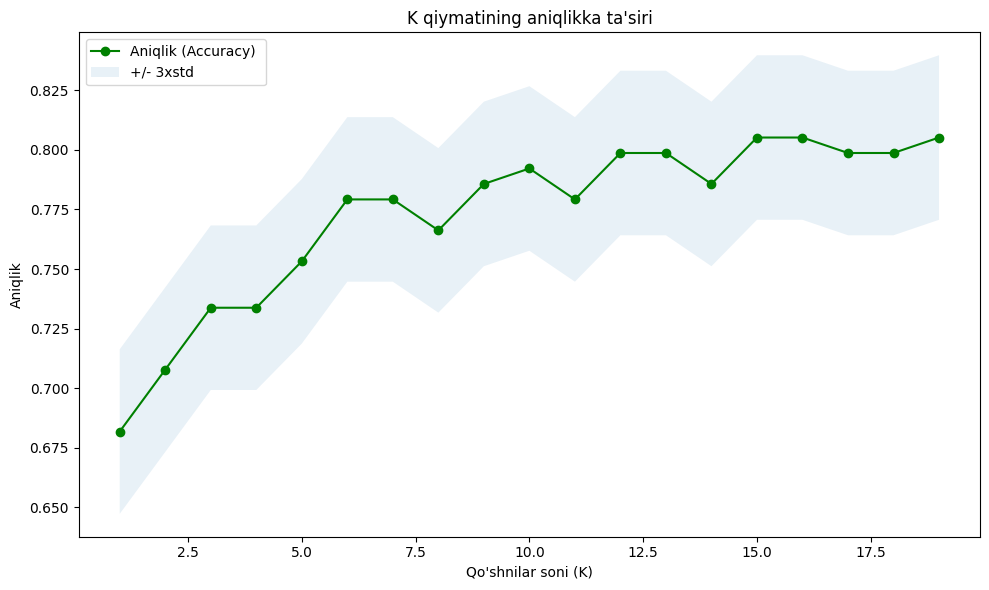

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = 20
mean_acc = np.zeros((ks-1))

for n in range(1, ks):
    # Har xil K (qo'shnilar) soni bilan modelni o'qitish
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train_scaler, y_train)
    yhat = neigh.predict(X_test_scaler)

    # Har bir K uchun aniqlikni hisoblab, massivga saqlash
    mean_acc[n-1] = accuracy_score(y_test, yhat)

# Eng yaxshi natija bergan K ni topish
print(f"Eng yaxshi aniqlik: {mean_acc.max():.2f}, K={mean_acc.argmax()+1} bo'lganda")

# Natijalarni grafikda chizish
plt.figure(figsize=(10,6))
plt.plot(range(1,ks), mean_acc, 'g', marker='o')
plt.fill_between(range(1,ks), mean_acc - 1 * np.std(mean_acc), mean_acc + 1 * np.std(mean_acc), alpha=0.10)
plt.title("K qiymatining aniqlikka ta'siri")
plt.legend(('Aniqlik (Accuracy) ', '+/- 3xstd'))
plt.ylabel('Aniqlik')
plt.xlabel('Qo\'shnilar soni (K)')
plt.tight_layout()
plt.show()

# Eng yaxshi aniqlik: 0.81, K=15 bo'lganda ekan endi k ni o'rniga 15 ni qo'yib yuqorida qilgan ishlarimizni takorlaymiz

In [71]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaler, y_train)

KNeighborsClassifier(n_neighbors=15)

In [72]:
y_predict=knn.predict(X_test_scaler)

In [73]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_predict)

np.float64(0.5454545454545454)

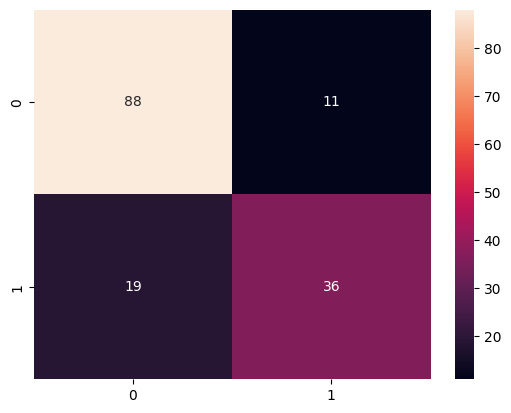

In [74]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

# Ko'rib turibmizki modelimiz umumiy aniqligi 81% ga yetdi

In [75]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        99
           1       0.77      0.65      0.71        55

    accuracy                           0.81       154
   macro avg       0.79      0.77      0.78       154
weighted avg       0.80      0.81      0.80       154



# Datamizni ustunlari soni kam edi atiga 768 ta edi uni biz 2 ga boldik train va test . Bizda bor datani Cross validation orqali modelga o'qitsak balkim aniqlik oshishi mumkin buni sinab ko'raylikchi.

In [76]:
# Cross validation
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X = X, y = y, cv = 5)

# Modelni baholash
from sklearn.metrics import classification_report
print("Classification Report: \n",classification_report(y, predict))

Classification Report: 
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       500
           1       0.65      0.53      0.59       268

    accuracy                           0.74       768
   macro avg       0.71      0.69      0.70       768
weighted avg       0.73      0.74      0.73       768



# Cross validation qilib o'qitganimizda 74% bo'ldi bu yomon emas model har xila malumotlar bilan ishlab real natijani berdi . bu tasodifan omadimiz kelganidan emas bu yaxshi

# GridSearchCV orqali eng yaxshi modelni aniqlash

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)

knn_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=15),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [79]:
knn_gscv.cv_results_['rank_test_score']

array([24, 23, 22, 21, 20, 19, 18,  6, 16, 11,  9,  3,  2,  1, 17, 15,  4,
        8,  5,  7, 12, 10, 13, 13], dtype=int32)

In [80]:
knn_gscv.best_params_

{'n_neighbors': np.int64(14)}

In [81]:
knn_gscv.best_score_

np.float64(0.7578558696205755)

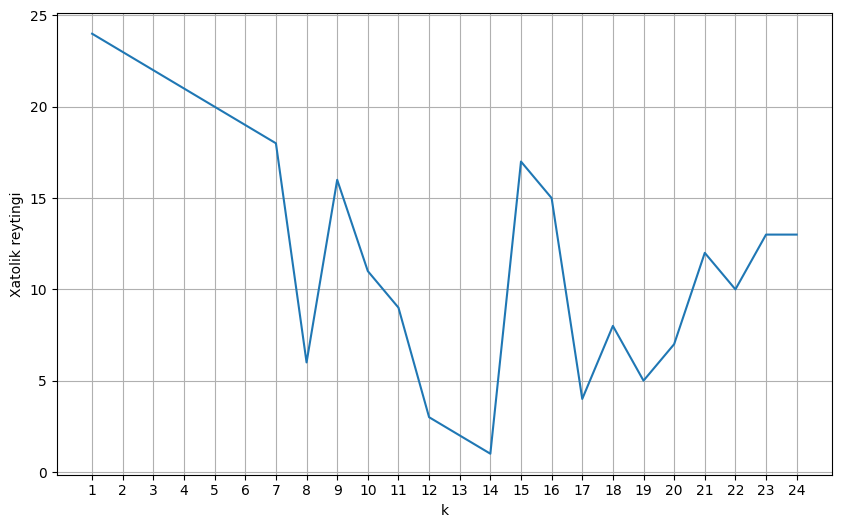

In [82]:
plt.figure(figsize=(10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()

In [83]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14)
knn.fit(X_train_scaler, y_train)

KNeighborsClassifier(n_neighbors=14)

In [84]:
y_predict=knn.predict(X_test_scaler)

In [85]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_predict)

np.float64(0.484375)

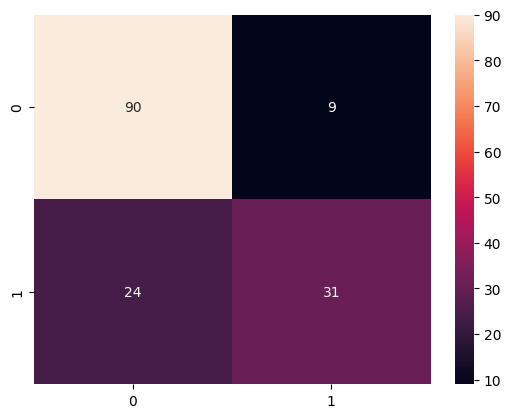

In [86]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

In [87]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85        99
           1       0.78      0.56      0.65        55

    accuracy                           0.79       154
   macro avg       0.78      0.74      0.75       154
weighted avg       0.78      0.79      0.78       154



k=14 qilganimizda modelni umumiy aniqligi 79% bo'ldi .
Hozircha k=15 qilganimizda modelimiz aniqroq ishlagandi .

# Endi ohirgi Jarayon
# yuqorida aytganimdek correlatsiya eng yuqori ustunlarni ajratib olamiz  va qayta modelga  o'qitamiz

In [110]:
df.corrwith(df['Outcome']).abs().sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [111]:
df_sara=df[['Outcome','Glucose','BMI','Age','Pregnancies']]
df_sara.head()

,Outcome,Glucose,BMI,Age,Pregnancies
0,1,148,33.6,50,6
1,0,85,26.6,31,1
2,1,183,23.3,32,8
3,0,89,28.1,21,1
4,1,137,43.1,33,0


# Yuqorida qilgan hamma ishlarimizni takrorlaymiz

In [112]:
X=df_sara.drop('Outcome', axis=1).values
y=df_sara['Outcome']

In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=12)

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [116]:
X_train_scaler=scaler.transform(X_train)
X_test_scaler=scaler.transform(X_test)

In [124]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaler, y_train)

KNeighborsClassifier(n_neighbors=13)

In [125]:
y_predict=knn.predict(X_test_scaler)

In [126]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_predict)

np.float64(0.5970149253731343)

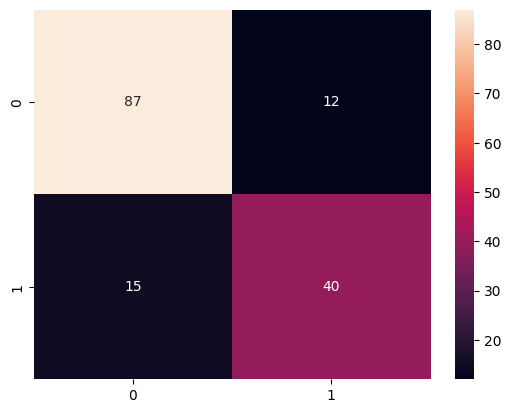

In [127]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

# KO'rib turganimizdek modelimizni aniqligi 82% bo'ldi

In [128]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        99
           1       0.77      0.73      0.75        55

    accuracy                           0.82       154
   macro avg       0.81      0.80      0.81       154
weighted avg       0.82      0.82      0.82       154



Eng yaxshi aniqlik: 0.82, K=13 bo'lganda


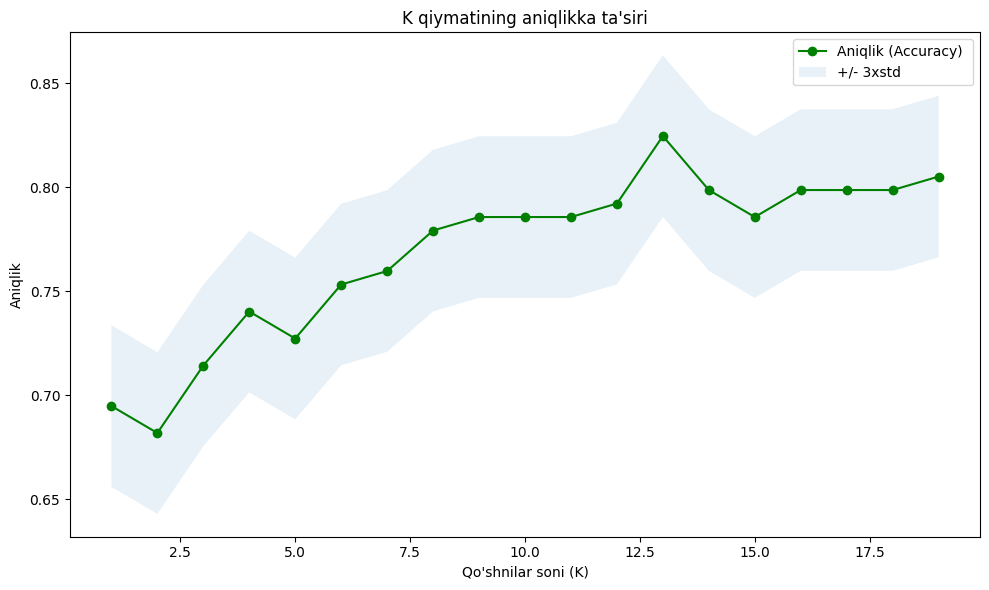

In [123]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score  # Mana shu qator xatoni tuzatadi!

ks = 20
mean_acc = np.zeros((ks-1))

for n in range(1, ks):
    # Har xil K (qo'shnilar) soni bilan modelni o'qitish
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train_scaler, y_train)
    yhat = neigh.predict(X_test_scaler)

    # Har bir K uchun aniqlikni hisoblab, massivga saqlash
    mean_acc[n-1] = accuracy_score(y_test, yhat)

# Eng yaxshi natija bergan K ni topish
print(f"Eng yaxshi aniqlik: {mean_acc.max():.2f}, K={mean_acc.argmax()+1} bo'lganda")

# Natijalarni grafikda chizish
plt.figure(figsize=(10,6))
plt.plot(range(1,ks), mean_acc, 'g', marker='o')
plt.fill_between(range(1,ks), mean_acc - 1 * np.std(mean_acc), mean_acc + 1 * np.std(mean_acc), alpha=0.10)
plt.title("K qiymatining aniqlikka ta'siri")
plt.legend(('Aniqlik (Accuracy) ', '+/- 3xstd'))
plt.ylabel('Aniqlik')
plt.xlabel('Qo\'shnilar soni (K)')
plt.tight_layout()
plt.show()

"Korrelyatsiya tahlili va natija: Loyihaning ushbu bosqichida modelga ta'sir qiluvchi ustunlar tahlil qilindi. Ma'lum bo'lishicha, barcha ustunlarni modelga kiritish har doim ham yaxshi natija bermaydi. Shuning uchun, maqsadli o'zgaruvchi (Outcome) bilan eng yuqori korrelyatsiyaga ega bo'lgan Glucose, BMI, Age va Pregnancies ustunlari ajratib olindi.

Optimallashtirish: Ushbu tanlangan ustunlar va GridSearchCV orqali topilgan K=13 parametridan foydalanilganda, modelning umumiy aniqligi (Accuracy) rekord darajadagi 82% ga yetdi. Bu dastlabki natijadan (75%) sezilarli darajada yuqoridir."